# Data Manipulation with Pandas & Visualization with Matplotlib & Seaborn

**Date:** 05/11/2025

In [1]:
#pip install pandas numpy matplotlib seaborn scikit-learn

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

| Columna     | Descripción                                                                                        |
|-------------|----------------------------------------------------------------------------------------------------|
| SalePrice   | El precio de venta de la propiedad en dólares. Esta es la variable objetivo que intentas predecir. |
| MSSubClass  | La clase de construcción (tipo de vivienda).                                                       |
| MSZoning    | La clasificación general de zonificación (uso del suelo).                                          |
| LotFrontage | Pies lineales de calle conectados a la propiedad.                                                  |
| LotArea     | Tamaño del lote o parcela en pies cuadrados.                                                       |
| Street      | Tipo de acceso a la carretera (ej. pavimentado o de grava).                                        |
| Alley       | Tipo de acceso al callejón (si lo tiene).                                                          |
| LotShape    | Forma general de la propiedad (ej. regular o ligeramente irregular).                               |
| LandContour | La llanura o el contorno del terreno de la propiedad.                                              |
| Utilities   | Tipo de servicios públicos disponibles (ej. agua, electricidad, gas).                              |
| LotConfig   | Configuración del lote (ej. en esquina, interior).                                                 |

* Melb Data: https://www.kaggle.com/code/dansbecker/handling-missing-values/data?select=melb_data.csv
* Sklearn Cheat Sheet from Datacamp: https://media.datacamp.com/legacy/image/upload/v1676302389/Marketing/Blog/Scikit-Learn_Cheat_Sheet.pdf

In [3]:
DATA_PATH = os.path.join(
    "/Users/cesar/sandbox/ai_programming_foundations/data",
    "melb_data.csv"
)

In [4]:
df = pd.read_csv(DATA_PATH)

Nota: Los objetos de Pandas se llaman **DataFrames**

In [5]:
df #.tail(5)

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000,S,Biggin,03/12/16,2.5,3067,...,1,1.0,202,NaN,NaN,Yarra,-37.79960,144.99840,Northern Metropolitan,4019
1,Abbotsford,25 Bloomburg St,2,h,1035000,S,Biggin,04/02/16,2.5,3067,...,1,0.0,156,79.0,1900.0,Yarra,-37.80790,144.99340,Northern Metropolitan,4019
2,Abbotsford,5 Charles St,3,h,1465000,SP,Biggin,04/03/17,2.5,3067,...,2,0.0,134,150.0,1900.0,Yarra,-37.80930,144.99440,Northern Metropolitan,4019
3,Abbotsford,40 Federation La,3,h,850000,PI,Biggin,04/03/17,2.5,3067,...,2,1.0,94,NaN,NaN,Yarra,-37.79690,144.99690,Northern Metropolitan,4019
4,Abbotsford,55a Park St,4,h,1600000,VB,Nelson,04/06/16,2.5,3067,...,1,2.0,120,142.0,2014.0,Yarra,-37.80720,144.99410,Northern Metropolitan,4019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13575,Wheelers Hill,12 Strada Cr,4,h,1245000,S,Barry,26/08/17,16.7,3150,...,2,2.0,652,NaN,1981.0,NaN,-37.90562,145.16761,South-Eastern Metropolitan,7392
13576,Williamstown,77 Merrett Dr,3,h,1031000,SP,Williams,26/08/17,6.8,3016,...,2,2.0,333,133.0,1995.0,NaN,-37.85927,144.87904,Western Metropolitan,6380
13577,Williamstown,83 Power St,3,h,1170000,S,Raine,26/08/17,6.8,3016,...,2,4.0,436,NaN,1997.0,NaN,-37.85274,144.88738,Western Metropolitan,6380
13578,Williamstown,96 Verdon St,4,h,2500000,PI,Sweeney,26/08/17,6.8,3016,...,1,5.0,866,157.0,1920.0,NaN,-37.85908,144.89299,Western Metropolitan,6380


In [6]:
df.columns

Index(['Suburb', 'Address', 'Rooms', 'Type', 'Price', 'Method', 'SellerG',
       'Date', 'Distance', 'Postcode', 'Bedroom2', 'Bathroom', 'Car',
       'Landsize', 'BuildingArea', 'YearBuilt', 'CouncilArea', 'Lattitude',
       'Longtitude', 'Regionname', 'Propertycount'],
      dtype='object')

In [7]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

In [8]:
# Columnas del clima
features = [
    'Rooms', 
    'BuildingArea',
    'Landsize',
    'Distance',
    'Bathroom',
    ]

# columna objectivo a predecir
target = ['Price']

In [43]:
df.filter(features+target).info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rooms         13580 non-null  int64  
 1   BuildingArea  7130 non-null   float64
 2   Landsize      13580 non-null  int64  
 3   Distance      13580 non-null  float64
 4   Bathroom      13580 non-null  int64  
 5   Price         13580 non-null  int64  
dtypes: float64(2), int64(4)
memory usage: 636.7 KB


In [ ]:
df.filter(features+target).describe()

,Rooms,BuildingArea,Landsize,Distance,Bathroom,Price
count,13580.000000,7130.000000,13580.000000,13580.000000,13580.000000,1.358000e+04
mean,2.937997,151.967650,558.416127,10.137776,1.534242,1.075684e+06
std,0.955748,541.014538,3990.669241,5.868725,0.691712,6.393107e+05
min,1.000000,0.000000,0.000000,0.000000,0.000000,8.500000e+04
25%,2.000000,93.000000,177.000000,6.100000,1.000000,6.500000e+05
50%,3.000000,126.000000,440.000000,9.200000,1.000000,9.030000e+05
75%,3.000000,174.000000,651.000000,13.000000,2.000000,1.330000e+06
max,10.000000,44515.000000,433014.000000,48.100000,8.000000,9.000000e+06


In [53]:
len(df_plots.columns)

6

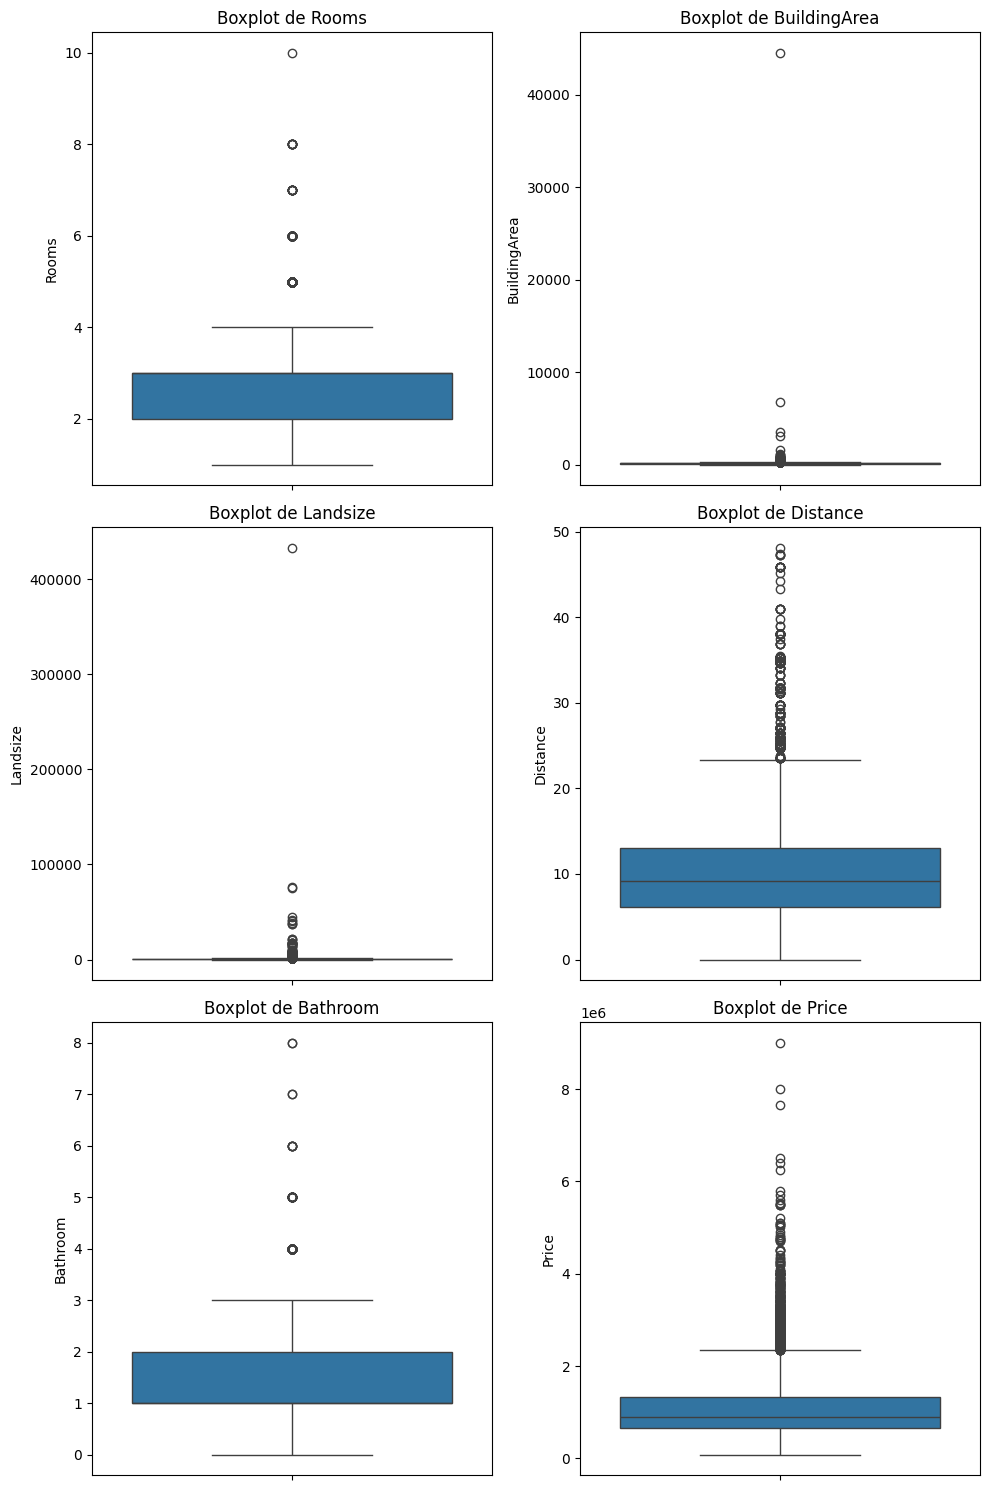

In [57]:
df_plots = df.filter(features+target)

# Determine the number of columns to plot
num_columns = len(df_plots.columns)
# Define the number of columns and calculate the number of rows needed
n_cols = 2 
n_rows = (num_columns + n_cols - 1) // n_cols

# Create a figure and a set of subplots
# Cambiamos la configuración de los subplots a (n_rows, n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 5), sharey=False)
axes = axes.flatten()

# Iterate through columns and plot each on its own subplot
for i, col in enumerate(df_plots.columns):
    sns.boxplot(y=df_plots[col], ax=axes[i], orient='v')
    axes[i].set_title(f'Boxplot de {col}')
    axes[i].set_ylabel(col) # Set individual y-axis label

# Ocultar los subplots sobrantes si 'num_columns' no es múltiplo de 'n_cols'
for j in range(num_columns, n_rows * n_cols):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

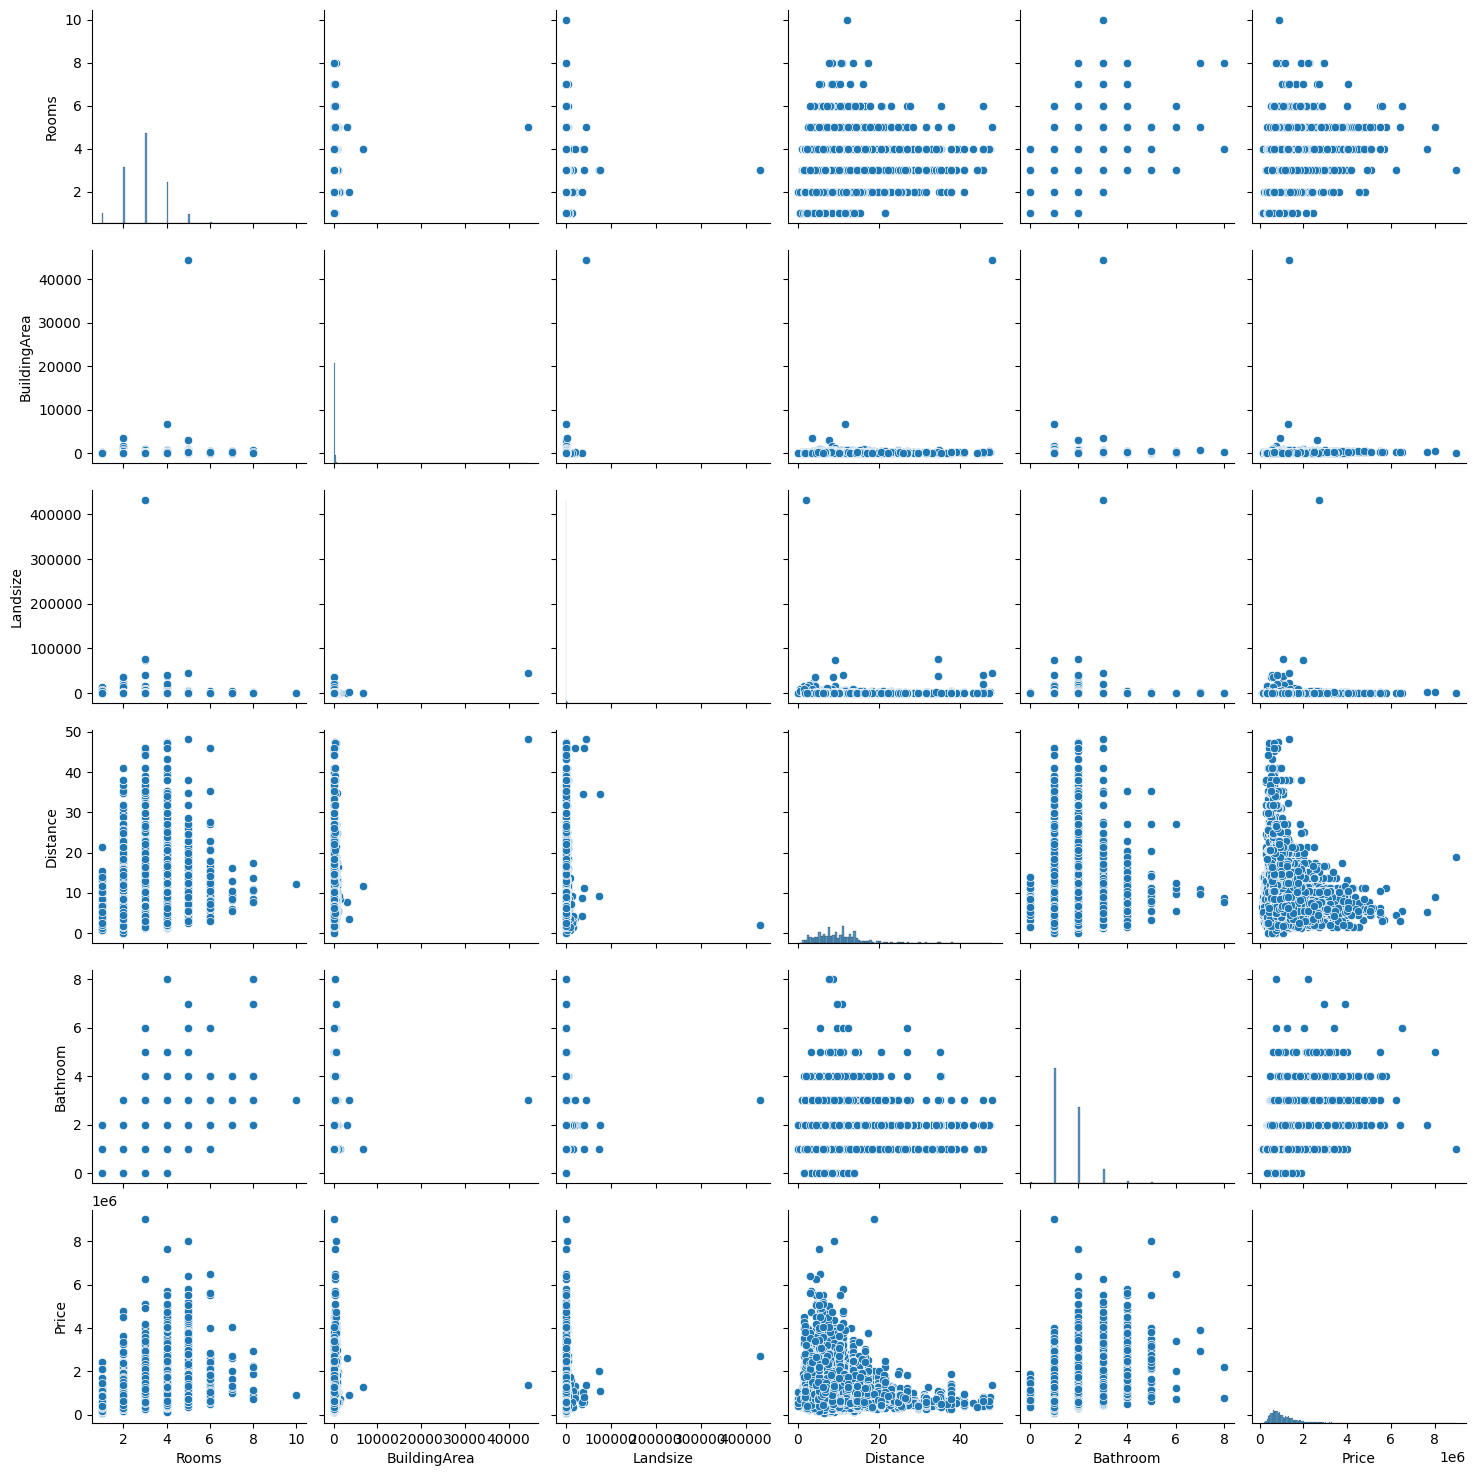

In [42]:
sns.pairplot(
    df.filter(features+target)
)

In [9]:
df[features+target].isna().sum()

Rooms              0
BuildingArea    6450
Landsize           0
Distance           0
Bathroom           0
Price              0
dtype: int64

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    df[features].fillna(0),
    df[target],
    test_size=0.2,
    random_state=210
)

In [11]:
# Modelo para 5 vecinos mas cercanos
model = KNeighborsRegressor(n_neighbors=5)

In [12]:
#model.__dict__

In [13]:
model.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [14]:
X_test.iloc[10] # tomamos un valor

Rooms             5.00
BuildingArea    182.85
Landsize        701.00
Distance         16.70
Bathroom          2.00
Name: 11375, dtype: float64

In [15]:
X_test.iloc[0].values.reshape(1, -1)

array([[ 2. , 62. ,  0. ,  4.6,  1. ]])

In [16]:
model.predict(X_test.iloc[0].values.reshape(1, -1)) # se lo damos al modelo para predecir

/Users/cesar/sandbox/ai_programming_foundations/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(


array([[468000.]])

In [17]:
# Predecimos para todos los datos del conjunto de entrenamiento y prueba
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

In [18]:
# error en conjunto de entrenamiento
error_train = mean_squared_error(y_train, y_train_pred)

# error en conjunto de prueba
error_test = mean_squared_error(y_test, y_test_pred)

In [19]:
print("Error RSME en train:", round(error_train,2) )

Error RSME en train: 164705819717.06


In [20]:
print("Error RSME en test:", round(error_test,2) )

Error RSME en test: 292857138013.22


In [21]:
y_train.values

array([[ 940000],
       [ 646250],
       [1110000],
       ...,
       [ 881000],
       [1310000],
       [1171000]], shape=(10864, 1))

In [22]:
eval_res = pd.DataFrame({
    "price": y_train.values.flatten(),
    "price_predicted": y_train_pred.flatten(),
})

In [23]:
eval_res["abs_error"] = np.abs(
    eval_res["price"]- eval_res["price_predicted"]
    )

In [24]:
eval_res

,price,price_predicted,abs_error
0,940000,1832400.0,892400.0
1,646250,919750.0,273500.0
2,1110000,1097800.0,12200.0
3,585000,1011000.0,426000.0
4,480750,573150.0,92400.0
...,...,...,...
10859,1401000,1681600.0,280600.0
10860,705000,1070100.0,365100.0
10861,881000,931200.0,50200.0
10862,1310000,1152900.0,157100.0


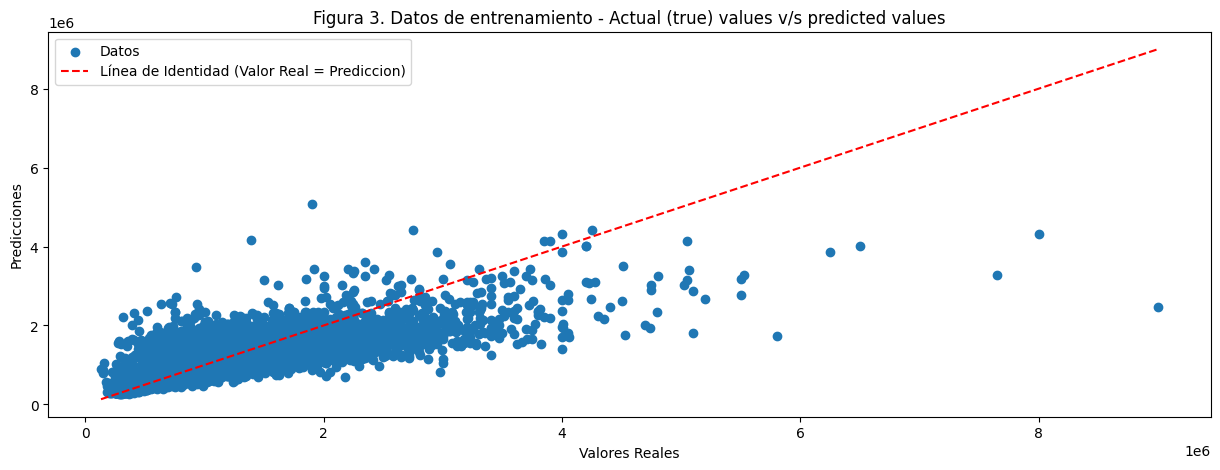

In [25]:
plt.figure(figsize=(15,5))

# Graficamos valores reales vs predicciones del modelo
plt.scatter(y_train.reset_index(drop=True), list(y_train_pred), label='Datos')
plt.title('Figura 3. Datos de entrenamiento - Actual (true) values v/s predicted values')

# Añadimos la identidad (x=y) para ver si el modelo es acertado

## valores max y min para limites de grafica
min_val = min(min(y_train.values.flatten()), min(list(y_train_pred)))
max_val = max(max(y_train.values.flatten()), max(list(y_train_pred)))

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color='red',
    linestyle='--',
    label='Línea de Identidad (Valor Real = Prediccion)'
)
# Etiquetas y titulos
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.legend()
plt.show()

<Axes: xlabel='abs_error', ylabel='Count'>

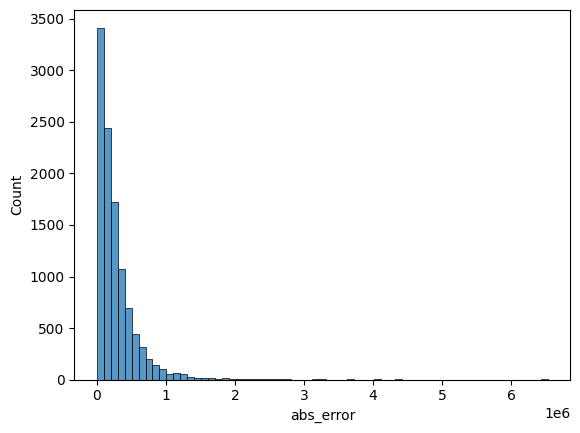

In [26]:
sns.histplot(
    eval_res,
    x="abs_error",
    binwidth=100_000
)

In [27]:
eval_res.query("abs_error < 2000").shape

(78, 3)

In [28]:
eval_res.query("abs_error  < 2000")

,price,price_predicted,abs_error
33,450000,451000.0,1000.0
138,1110000,1108600.0,1400.0
414,1270000,1269000.0,1000.0
417,612500,613500.0,1000.0
537,2050000,2049600.0,400.0
...,...,...,...
10453,505000,506400.0,1400.0
10507,1175000,1176200.0,1200.0
10526,685000,685000.0,0.0
10806,860000,861000.0,1000.0


In [ ]:
neighbours = [1, 2, 5, 10, 20, 50, 70, 100]

models_regresion = {
    i: KNeighborsRegressor(n_neighbors=i)
    for i in neighbours
    }


In [30]:
models_regresion

{1: KNeighborsRegressor(n_neighbors=1),
 2: KNeighborsRegressor(n_neighbors=2),
 5: KNeighborsRegressor(),
 10: KNeighborsRegressor(n_neighbors=10),
 20: KNeighborsRegressor(n_neighbors=20),
 50: KNeighborsRegressor(n_neighbors=50),
 70: KNeighborsRegressor(n_neighbors=70),
 100: KNeighborsRegressor(n_neighbors=100)}

In [31]:
errors_train = []
errors_test = []

for model_name in models_regresion.keys():

    print("Modelo:", model_name)
    model = models_regresion[model_name]

    # Ajusta el modelo con los datos de prueba
    model.fit(X_train,y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # error en conjunto de entrenamiento y prueba
    error_train = mean_squared_error(y_train, y_train_pred)
    error_test = mean_squared_error(y_test, y_test_pred)

    errors_train.append(error_train)
    errors_test.append(error_test)

    # errores
    print("Error RSME en train:", round(error_train,2) )
    print("Error RSME en test:", round(error_test,2) )

    print("----------------------------------------------")

    


Modelo: 1
Error RSME en train: 4718348084.13
Error RSME en test: 431608907931.02
----------------------------------------------
Modelo: 2
Error RSME en train: 91041937060.33
Error RSME en test: 338241430400.71
----------------------------------------------
Modelo: 5
Error RSME en train: 164705819717.06
Error RSME en test: 292857138013.22
----------------------------------------------
Modelo: 10
Error RSME en train: 199050460154.9
Error RSME en test: 273946571133.42
----------------------------------------------
Modelo: 20
Error RSME en train: 228063147146.65
Error RSME en test: 273003608757.15
----------------------------------------------
Modelo: 50
Error RSME en train: 256854034802.5
Error RSME en test: 286773015733.49
----------------------------------------------
Modelo: 70
Error RSME en train: 267739307128.78
Error RSME en test: 293412963070.55
----------------------------------------------
Modelo: 100
Error RSME en train: 277627824604.53
Error RSME en test: 300313061887.06
------

In [32]:
knn_errors_train = pd.DataFrame(
    {
        "k": neighbours,
        "type": "train",
        "rmse": errors_train,
    }
)

knn_errors_test = pd.DataFrame(
    {
        "k": neighbours,
        "type": "test",
        "rmse": errors_test,
    }
)

In [33]:
pd.concat([knn_errors_train, knn_errors_test])

,k,type,rmse
0,1,train,4.718348e+09
1,2,train,9.104194e+10
2,5,train,1.647058e+11
3,10,train,1.990505e+11
4,20,train,2.280631e+11
5,50,train,2.568540e+11
6,70,train,2.677393e+11
7,100,train,2.776278e+11
0,1,test,4.316089e+11
1,2,test,3.382414e+11


In [34]:
knn_errors = pd.DataFrame(
    {
        "k": neighbours,
        "rmse_train": errors_train,
        "rmse_test": errors_test
    }
)

knn_errors

,k,rmse_train,rmse_test
0,1,4.718348e+09,4.316089e+11
1,2,9.104194e+10,3.382414e+11
2,5,1.647058e+11,2.928571e+11
3,10,1.990505e+11,2.739466e+11
4,20,2.280631e+11,2.730036e+11
5,50,2.568540e+11,2.867730e+11
6,70,2.677393e+11,2.934130e+11
7,100,2.776278e+11,3.003131e+11


<Axes: xlabel='k', ylabel='rmse'>

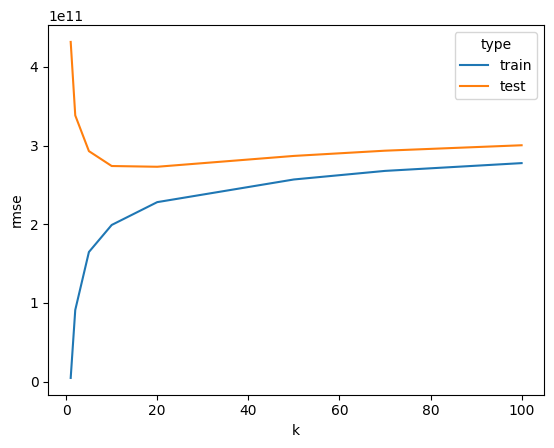

In [35]:
sns.lineplot(
    pd.concat([knn_errors_train, knn_errors_test]),
    x="k",
    y="rmse",
    hue="type",
    markers=True, dashes=True
)

**Questions:**

* Repite el ejercicio pero incorporando más columnas de tipo numérico (por ejemplo `YearBuilt`)
  * Si existen valores nulos asegurate de imputarles un valor usando la media de dicha columna
* Usando este nuevo ejercicio contesta:
  * ¿El error aumento o disminuyo?,
  * ¿Cual fue el numero de vecino?